Topic 0 : ['mileage', 'high', 'value', 'money', 'car']
Topic 1 : ['features', 'comfort', 'excellent', 'service', 'satisfied']
Topic 2 : ['comfort', 'better', 'could', 'terms', 'features']


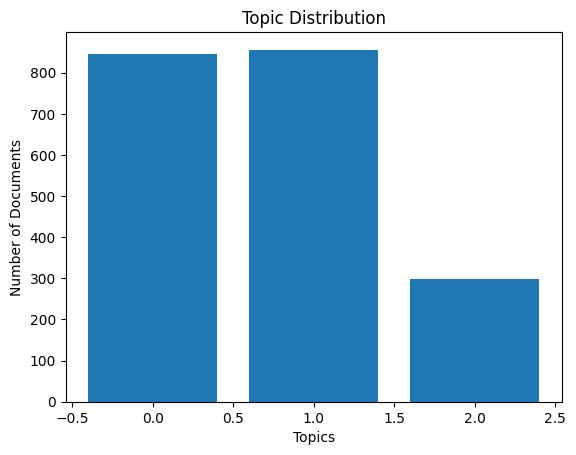

In [9]:
import pandas as pd
import re
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt

# load data
df = pd.read_csv("car_showroom_dataset.csv")

# basic cleaning
df = df.dropna().drop_duplicates()

# simple preprocessing
stop_words = set(stopwords.words('english'))

def clean(text):
    text = text.lower()
    text = re.sub("[^a-z ]", "", text)
    words = text.split()
    return " ".join([w for w in words if w not in stop_words])

df["clean"] = df["customer_review"].apply(clean)

# text → numbers
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["clean"])

# apply LDA
lda = LatentDirichletAllocation(n_components=3)
lda.fit(X)

# print topics
words = vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    print("Topic", i, ":", [words[j] for j in topic.argsort()[-5:]])


# topic distribution
topic_values = lda.transform(X)
top_topics = topic_values.argmax(axis=1)

counts = pd.Series(top_topics).value_counts().sort_index()

# plot
plt.bar(counts.index, counts.values)
plt.xlabel("Topics")
plt.ylabel("Number of Documents")
plt.title("Topic Distribution")
plt.show()